# 머신러닝 분류 모델

In [1]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams["axes.unicode_minus"] = False # - 부호 깨짐 방지

In [5]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터셋 -> 학습용 / 테스트용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("\nData split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Data split into training and testing sets.
X_train shape: (455, 30), y_train shape: (455,)
X_test shape: (114, 30), y_test shape: (114,)

Features scaled using StandardScaler.
X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


# 로지스틱 회귀 모델 학습 및 평가

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained.")

y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# calculate accuracy score
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"\nLogistic Regression Model Accuracy: {accuracy_log_reg:.4f}")

# store model results
model_accuracies = {}
model_accuracies["Logistic Regression"] = accuracy_log_reg

Logistic Regression model trained.

Logistic Regression Model Accuracy: 0.9825


# 의사결정나무 모델 학습 및 평가

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)
y_pred_dt = decision_tree_model.predict(X_test_scaled)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Classifier Model Accuracy: {accuracy_dt:.4f}")

model_accuracies["Decision Tree"] = accuracy_dt


Decision Tree Classifier Model Accuracy: 0.9123


# 의사결정나무 시각화 및 특성 중요도

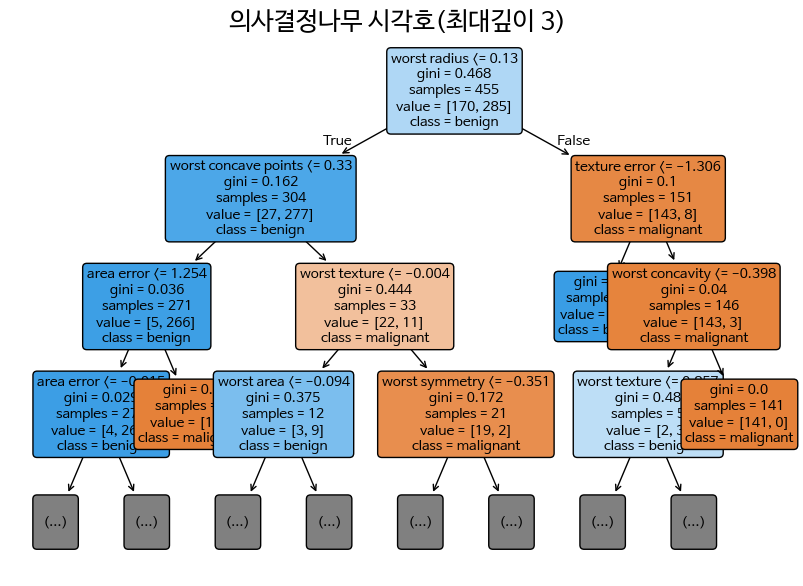

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(decision_tree_model,
          feature_names=cancer.feature_names,
          class_names=cancer.target_names,
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("의사결정나무 시각호(최대깊이 3)", fontsize=18)
plt.show()

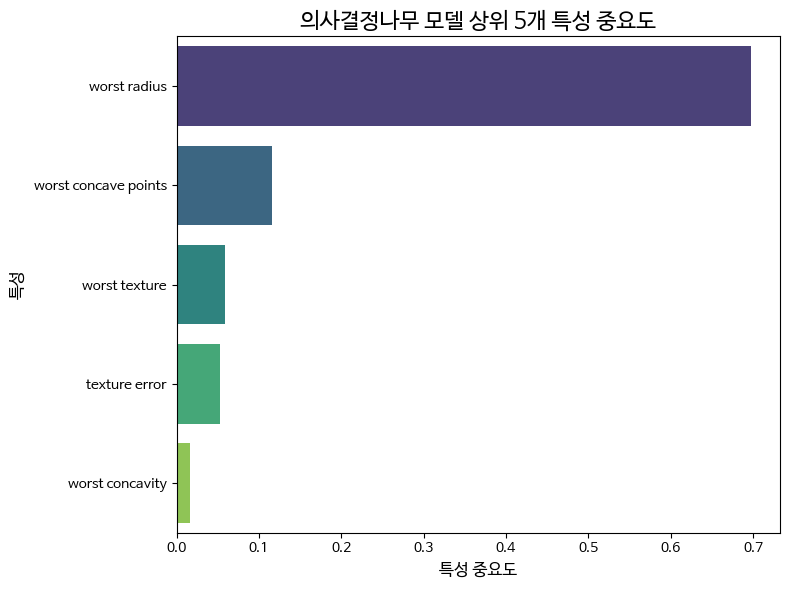

In [10]:
feature_importances = pd.Series(
    decision_tree_model.feature_importances_,
    index=cancer.feature_names
)

# Sort feature importances in descending order and select the top 5
# pandas.Series에서 nlargest() 기능 제공
top_5_features = feature_importances.nlargest(5)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_5_features.values, y=top_5_features.index, palette='viridis')
plt.title('의사결정나무 모델 상위 5개 특성 중요도', fontsize=16)
plt.xlabel('특성 중요도', fontsize=12)
plt.ylabel('특성', fontsize=12)
plt.tight_layout()
plt.show()

# 랜덤포레스트 모델 학습 및 평가

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_scaled , y_train)
y_pred_rf = random_forest_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Classifier Model Accuracy: {accuracy_rf:.4f}")

model_accuracies["Random Forest"] = accuracy_rf


Random Forest Classifier Model Accuracy: 0.9561


# 랜덤포레스트 특성 중요도 시각화

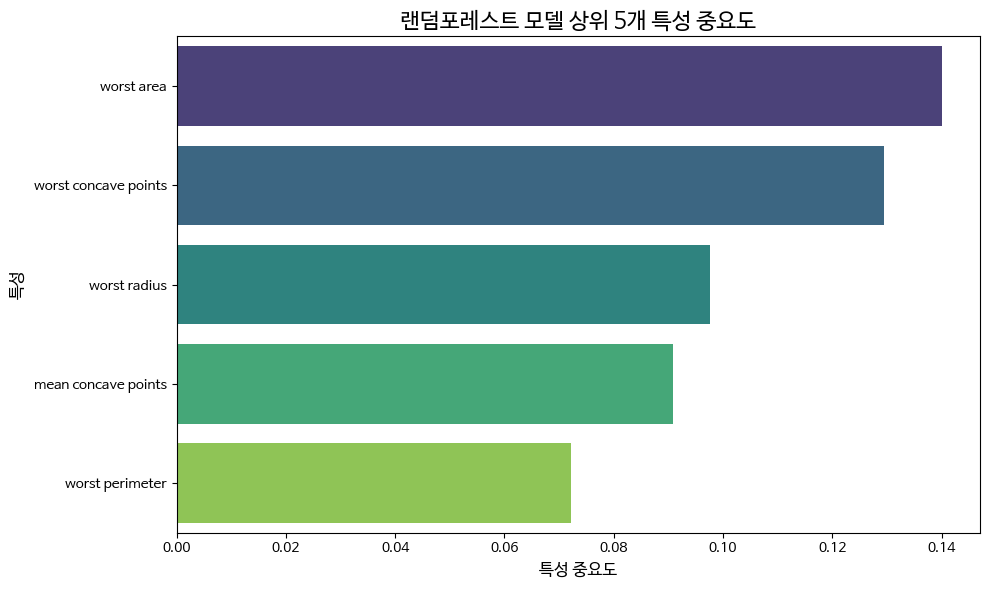

In [12]:
feature_importances_rf = pd.Series(
    random_forest_model.feature_importances_,
    index=cancer.feature_names
)

top_5_features_rf = feature_importances_rf.nlargest(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_features_rf.values, y=top_5_features_rf.index,
            hue=top_5_features_rf.index, palette='viridis', legend=False)
plt.title('랜덤포레스트 모델 상위 5개 특성 중요도', fontsize=16)
plt.xlabel('특성 중요도', fontsize=12)
plt.ylabel('특성', fontsize=12)
plt.tight_layout()
plt.show()

# KNN 모델 학습 및 평가

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nK-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")

model_accuracies["K-Nearest Neighbors"] = accuracy_knn


K-Nearest Neighbors Model Accuracy: 0.9561


# KNN K값 변화에 따른 정확도 시각화

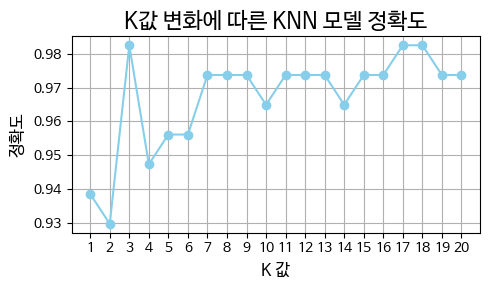

In [17]:
k_values = []
k_accuracies = []

for k in range(1, 21): # 1 to 20
  knn = KNeighborsClassifier(n_neighbors=k)

  knn.fit(X_train_scaled, y_train)
  y_pred_k = knn.predict(X_test_scaled)

  accuracy = accuracy_score(y_test, y_pred_k)
  k_values.append(k)
  k_accuracies.append(accuracy)

plt.figure(figsize=(5, 3))
plt.plot(k_values, k_accuracies, marker='o', linestyle='-', color='skyblue')
plt.title('K값 변화에 따른 KNN 모델 정확도', fontsize=16)
plt.xlabel('K 값', fontsize=12)
plt.ylabel('정확도', fontsize=12)
plt.xticks(range(1, 21)) # Ensure x-axis ticks show each K value
plt.grid(True)
plt.tight_layout()
plt.show()

# 나이브 베이즈 모델 학습 및 평가

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred_gnb = gnb_model.predict(X_test_scaled)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"\nGaussian Naive Bayes Model Accuracy: {accuracy_gnb:.4f}")

model_accuracies["Gaussian Naive Bayes"] = accuracy_gnb


Gaussian Naive Bayes Model Accuracy: 0.9298


# SVM 모델 학습 및 평가

In [20]:
from sklearn.svm import SVC # SVR과 구분. SVC가 분류 모델
from sklearn.metrics import accuracy_score

svc_model = SVC(random_state=42)

svc_model.fit(X_train_scaled, y_train)
y_pred_svm = svc_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSupport Vector Machine (SVC) Model Accuracy: {accuracy_svm:.4f}")

model_accuracies["Support Vector Machine"] = accuracy_svm


Support Vector Machine (SVC) Model Accuracy: 0.9825


## 전체 모델 정확도 비교 시각화 및 최고 성능 모델 출력

- 앞서 계산하여 저장해 둔 모든 분류 모델(로지스틱 회귀, 의사결정나무, 랜덤포레스트, KNN, 나이브 베이즈, SVM)의 정확도를 하나의 막대그래프로 비교 시각화

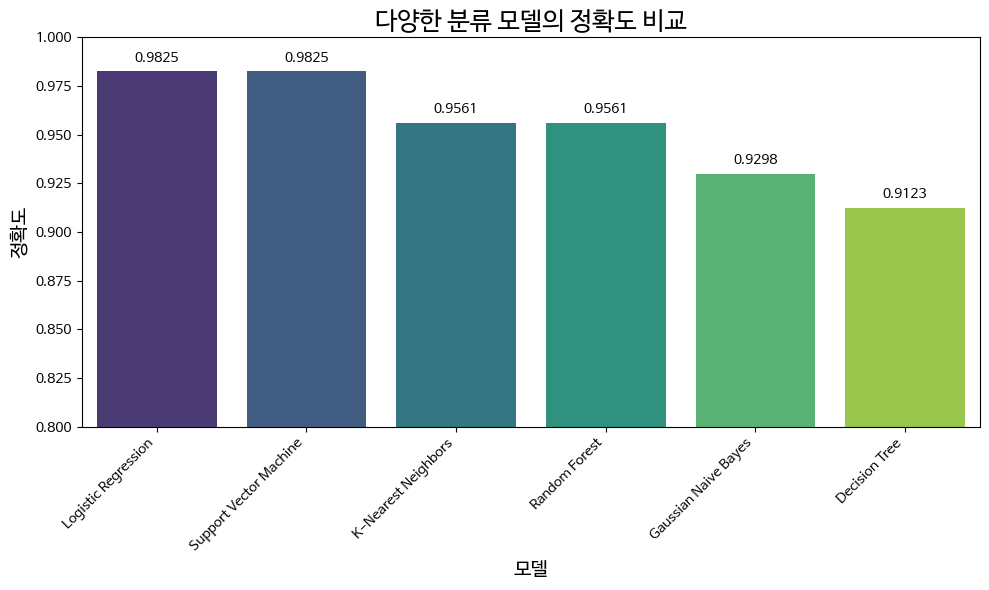

In [21]:
accuracies_series = pd.Series(model_accuracies)

accuracies_series = accuracies_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies_series.index, y=accuracies_series.values, palette='viridis')
plt.title('다양한 분류 모델의 정확도 비교', fontsize=18)
plt.xlabel('모델', fontsize=14)
plt.ylabel('정확도', fontsize=14)
plt.ylim(0.8, 1.0) # Set y-axis limits to better show differences
plt.xticks(rotation=45, ha='right') # Rotate model names for better readability

# Add accuracy values on top of the bars
for index, value in enumerate(accuracies_series.values):
    plt.text(index, value + 0.005, f'{value:.4f}', color='black', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
best_model_name = accuracies_series.idxmax()
best_accuracy = accuracies_series.max()

print(f"\n가장 높은 정확도를 보인 모델: {best_model_name} (정확도: {best_accuracy:.4f})")


가장 높은 정확도를 보인 모델: Logistic Regression (정확도: 0.9825)
